In [8]:
from Pose_Preprocessing_Pipeline_pasp import *

Removed 19 videos due to missing frames:
['semantic_segmentation_PA027_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA366_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA250_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA016_FGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA239_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA203_UGS_WoJ_1_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA292_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA140_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA375_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA267_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA031_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA336_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA383_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA026_FGS_WoJ_2_DensePose_lan

In [10]:
# get the patient_name_clean
# Extract video_id from window_ids_clean (assuming format: "video_id_winXXX_fYYY-ZZZ")
video_ids_clean = [w.split("_win")[0] for w in window_ids_clean]

# Build mapping from df_video: video_id -> patient_name
video_to_patient = dict(zip(df_video["video_id"], df_video["patient_name"]))

# Map window_ids to patient names
patient_names_clean = np.array([video_to_patient[vid] for vid in video_ids_clean])
print(f"Patient names for QC-clean windows: {patient_names_clean.shape}")
print(f"Unique patients: {len(np.unique(patient_names_clean))}")


Patient names for QC-clean windows: (15001,)
Unique patients: 409


In [11]:
# %%
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# -------------------------------
# Assume after QC you have:
# X_clean: (N_windows, T, J, 3)
# y_binary_clean: (N_windows,)
# y_multilabel_clean: (N_windows, 5)
# window_ids_clean: list of window IDs
# patient_names_clean: list/array of patient_name per window
# -------------------------------

# Example:
# patient_names_clean = df_window['patient_name'].to_numpy()  

# ============================================================
# 🔹 NEW BLOCK — ADD THIS RIGHT HERE (after QC, before split)
# ============================================================

# GAIT joint indices (must match your gait14_graph node order)
GAIT_JOINTS = [
    2, 5,     # eyes
    11, 12,   # shoulders
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
    29, 30,   # heels
    31, 32    # foot index
]

# Select only gait joints
#X_clean = X_clean[:, :, GAIT_JOINTS, :]   # (N, T, 14, 3)

print("After joint selection:", X_clean.shape)
# MUST be: (N_windows, T, 14, 3)

# ============================================================
# 🔹 END NEW BLOCK
# ============================================================

# -------------------------------
# 1. Patient-level train/test split
# -------------------------------
unique_patients = np.unique(patient_names_clean)
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

# Mask windows by patient
train_mask = np.isin(patient_names_clean, train_patients)
test_mask  = np.isin(patient_names_clean, test_patients)

# Apply masks
X_train = X_clean[train_mask]
X_test  = X_clean[test_mask]
y_bin_train = y_binary_clean[train_mask]
y_bin_test  = y_binary_clean[test_mask]
y_ml_train  = y_multilabel_clean[train_mask]
y_ml_test   = y_multilabel_clean[test_mask]

print(f"Train windows: {X_train.shape[0]}, Test windows: {X_test.shape[0]}")

# -------------------------------
# 2. Transpose to ST-GCN format: (N, C=3, T, V)
# -------------------------------
X_train_stgcn = np.transpose(X_train, (0, 3, 1, 2))
X_test_stgcn  = np.transpose(X_test,  (0, 3, 1, 2))

# Add person dimension (M=1)
X_train_stgcn = X_train_stgcn[..., np.newaxis]
X_test_stgcn  = X_test_stgcn[..., np.newaxis]


print(f"ST-GCN input shape train: {X_train_stgcn.shape}, test: {X_test_stgcn.shape}")

# -------------------------------
# 3. Separate abnormal windows for multi-label model
# -------------------------------
abnormal_mask_train = y_bin_train == 1
abnormal_mask_test  = y_bin_test == 1

X_ml_train_stgcn = X_train_stgcn[abnormal_mask_train]
y_ml_train_filtered = y_ml_train[abnormal_mask_train]

X_ml_test_stgcn = X_test_stgcn[abnormal_mask_test]
y_ml_test_filtered = y_ml_test[abnormal_mask_test]

print(f"Multi-label train windows: {X_ml_train_stgcn.shape[0]}, test windows: {X_ml_test_stgcn.shape[0]}")

After joint selection: (15001, 60, 14, 3)
Train windows: 11874, Test windows: 3127
ST-GCN input shape train: (11874, 3, 60, 14, 1), test: (3127, 3, 60, 14, 1)
Multi-label train windows: 460, test windows: 355


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

class GaitDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # ensure float
        self.y = torch.tensor(y, dtype=torch.float32)  # float for BCE, long for CE

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Binary
train_dataset_bin = GaitDataset(X_train_stgcn, y_bin_train)
test_dataset_bin  = GaitDataset(X_test_stgcn, y_bin_test)

train_loader_bin = DataLoader(train_dataset_bin, batch_size=32, shuffle=True)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=32, shuffle=False)

# Multi-label
train_dataset_ml = GaitDataset(X_ml_train_stgcn, y_ml_train_filtered)
test_dataset_ml  = GaitDataset(X_ml_test_stgcn, y_ml_test_filtered)

train_loader_ml = DataLoader(train_dataset_ml, batch_size=32, shuffle=True)
test_loader_ml  = DataLoader(test_dataset_ml, batch_size=32, shuffle=False)


Train windows: 11874, Test windows: 3127

=== Binary | Window-level ===
Accuracy: 0.9878477774224497
F1: 0.9450867052023121
Precision: 0.9703264094955489
Recall: 0.9211267605633803
AUROC: 0.998174908034063
Confusion matrix:
 [[2762   10]
 [  28  327]]

=== Binary | Patient-level ===
Accuracy: 1.0
F1: 1.0
Precision: 1.0
Recall: 1.0
AUROC: 1.0
Confusion matrix:
 [[77  0]
 [ 0  5]]


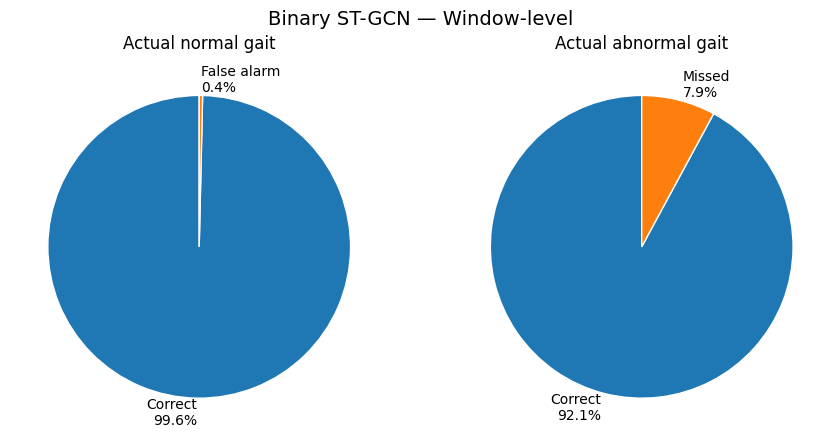

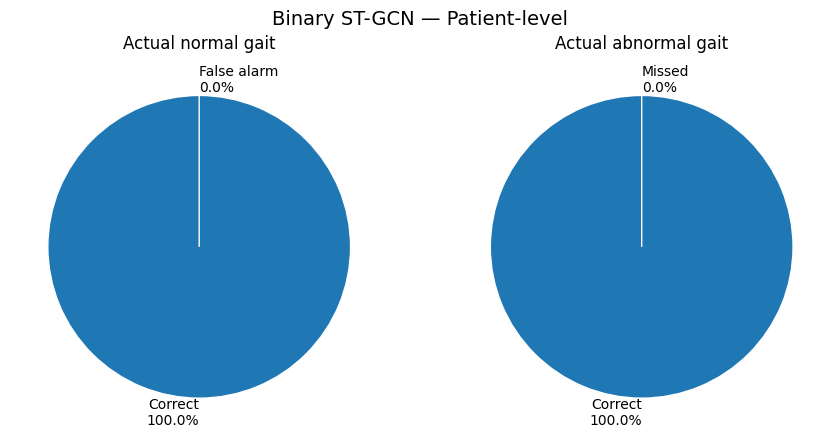


=== Multilabel | Window-level ===
Accuracy: 0.29014084507042254
F1 (macro): 0.11852155208074792
Confusion matrix:
 [[98 69 39 37  8]
 [34  1 14 34  0]
 [ 0  0  0  0  0]
 [12  0  2  4  3]
 [ 0  0  0  0  0]]

=== Multilabel | Patient-level ===
Accuracy: 0.0
F1 (macro): 0.0
Confusion matrix:
 [[0 1 2 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]]


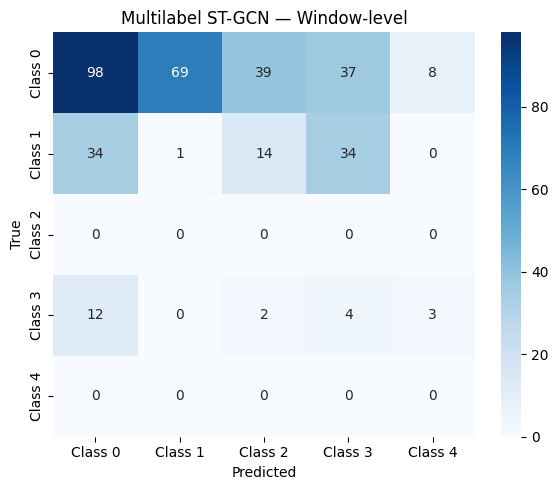

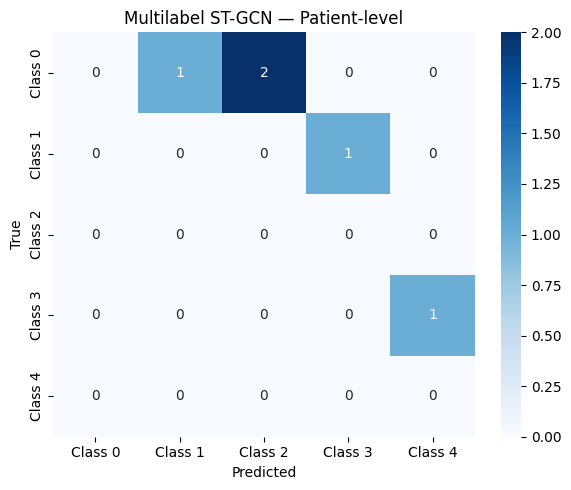

In [26]:
# ============================================================
# FULL FIXED ST-GCN EVALUATION SCRIPT
# ============================================================

import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)

# ============================================================
# Add models folder to path
# ============================================================
sys.path.append("../models")  # adjust if needed
from net.st_gcn import Model
from net.gait14_graph import Graph as GaitGraph

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Model checkpoint paths
# ============================================================
BINARY_MODEL_PATH = Path("../models/binary_stgcn_gait14_improved_stadedict.bin")
MULTI_MODEL_PATH  = Path("../models/multilabel_stgcn_state_dict.bin")

# ============================================================
# Load state_dicts
# ============================================================
binary_state_dict = torch.load(BINARY_MODEL_PATH, map_location=device)
multi_state_dict  = torch.load(MULTI_MODEL_PATH, map_location=device)

# ============================================================
# Plotting helpers
# ============================================================
def plot_out_of_100_pies(cm, title):
    normal_row = cm[0] / cm[0].sum()
    abnormal_row = cm[1] / cm[1].sum()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    fig.suptitle(title, fontsize=14)

    axes[0].pie(
        [normal_row[0]*100, normal_row[1]*100],
        labels=[f"Correct\n{normal_row[0]*100:.1f}%", f"False alarm\n{normal_row[1]*100:.1f}%"],
        startangle=90, wedgeprops={"edgecolor": "white"}
    )
    axes[0].set_title("Actual normal gait")

    axes[1].pie(
        [abnormal_row[1]*100, abnormal_row[0]*100],
        labels=[f"Correct\n{abnormal_row[1]*100:.1f}%", f"Missed\n{abnormal_row[0]*100:.1f}%"],
        startangle=90, wedgeprops={"edgecolor": "white"}
    )
    axes[1].set_title("Actual abnormal gait")
    plt.tight_layout()
    plt.show()

def plot_confusion_heatmap(cm, title, class_names):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ============================================================
# Dataset wrapper
# ============================================================
class GaitDataset(Dataset):
    def __init__(self, X, y, patient_names=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32 if len(y.shape) > 1 else torch.long)
        self.pids = np.array(patient_names) if patient_names is not None else np.arange(len(y))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.pids[idx]

# ============================================================
# Assume X_clean, y_binary_clean, y_multilabel_clean, patient_names_clean are defined
# X_clean shape: (N_windows, T, 14, 3)
# ============================================================

# -------------------------------
# Patient-level train/test split
# -------------------------------
from sklearn.model_selection import train_test_split
unique_patients = np.unique(patient_names_clean)
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

train_mask = np.isin(patient_names_clean, train_patients)
test_mask  = np.isin(patient_names_clean, test_patients)

# Apply masks
X_train = X_clean[train_mask]
X_test  = X_clean[test_mask]
y_bin_train = y_binary_clean[train_mask]
y_bin_test  = y_binary_clean[test_mask]
y_ml_train  = y_multilabel_clean[train_mask]
y_ml_test   = y_multilabel_clean[test_mask]
patient_train = patient_names_clean[train_mask]
patient_test  = patient_names_clean[test_mask]

print(f"Train windows: {X_train.shape[0]}, Test windows: {X_test.shape[0]}")

# -------------------------------
# Transpose to ST-GCN format: (N, C=3, T, V), add M=1 dimension
# -------------------------------
X_train_stgcn = X_train.transpose(0, 3, 1, 2)[..., np.newaxis]  # (N, 3, T, 14, 1)
X_test_stgcn  = X_test.transpose(0, 3, 1, 2)[..., np.newaxis]

# -------------------------------
# Create DataLoaders
# -------------------------------
batch_size = 32

# Binary
train_dataset_bin = GaitDataset(X_train_stgcn, y_bin_train, patient_train)
test_dataset_bin  = GaitDataset(X_test_stgcn, y_bin_test, patient_test)
train_loader_bin = DataLoader(train_dataset_bin, batch_size=batch_size, shuffle=True)
test_loader_bin  = DataLoader(test_dataset_bin, batch_size=batch_size, shuffle=False)

# Multilabel (only abnormal windows)
abnormal_mask_train = y_bin_train == 1
abnormal_mask_test  = y_bin_test == 1
X_ml_train_stgcn = X_train_stgcn[abnormal_mask_train]
y_ml_train_filtered = y_ml_train[abnormal_mask_train]
patient_ml_train = patient_train[abnormal_mask_train]

X_ml_test_stgcn = X_test_stgcn[abnormal_mask_test]
y_ml_test_filtered = y_ml_test[abnormal_mask_test]
patient_ml_test = patient_test[abnormal_mask_test]

train_dataset_ml = GaitDataset(X_ml_train_stgcn, y_ml_train_filtered, patient_ml_train)
test_dataset_ml  = GaitDataset(X_ml_test_stgcn, y_ml_test_filtered, patient_ml_test)
train_loader_ml = DataLoader(train_dataset_ml, batch_size=batch_size, shuffle=True)
test_loader_ml  = DataLoader(test_dataset_ml, batch_size=batch_size, shuffle=False)

# ============================================================
# BINARY ST-GCN
# ============================================================
binary_stgcn = Model(
    in_channels=3,
    num_class=1,
    edge_importance_weighting=True,
    graph_args={}
).to(device)
binary_stgcn.load_state_dict(binary_state_dict)
binary_stgcn.eval()

all_probs, all_targets, all_patients = [], [], []

with torch.no_grad():
    for X_batch, y_batch, pids in test_loader_bin:
        X_batch = X_batch.to(device)
        logits = binary_stgcn(X_batch).squeeze(1)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(y_batch.detach().cpu().numpy())
        all_patients.append(np.array(pids))

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)
all_patients = np.concatenate(all_patients)

window_preds = (all_probs > 0.5).astype(int)
cm_window_bin = confusion_matrix(all_targets, window_preds)

print("\n=== Binary | Window-level ===")
print("Accuracy:", accuracy_score(all_targets, window_preds))
print("F1:", f1_score(all_targets, window_preds))
print("Precision:", precision_score(all_targets, window_preds))
print("Recall:", recall_score(all_targets, window_preds))
print("AUROC:", roc_auc_score(all_targets, all_probs))
print("Confusion matrix:\n", cm_window_bin)

# Patient-level
unique_patients = np.unique(all_patients)
patient_preds, patient_probs, patient_true = [], [], []

for pid in unique_patients:
    mask = all_patients == pid
    patient_preds.append(int(np.round(window_preds[mask].mean())))
    patient_probs.append(all_probs[mask].max())
    patient_true.append(int(np.round(all_targets[mask].mean())))

patient_preds = np.array(patient_preds)
patient_probs = np.array(patient_probs)
patient_true  = np.array(patient_true)
cm_patient_bin = confusion_matrix(patient_true, patient_preds)

print("\n=== Binary | Patient-level ===")
print("Accuracy:", accuracy_score(patient_true, patient_preds))
print("F1:", f1_score(patient_true, patient_preds))
print("Precision:", precision_score(patient_true, patient_preds))
print("Recall:", recall_score(patient_true, patient_preds))
print("AUROC:", roc_auc_score(patient_true, patient_probs))
print("Confusion matrix:\n", cm_patient_bin)

plot_out_of_100_pies(cm_window_bin, "Binary ST-GCN — Window-level")
plot_out_of_100_pies(cm_patient_bin, "Binary ST-GCN — Patient-level")

# ============================================================
# MULTILABEL ST-GCN
# ============================================================
num_classes = y_ml_train_filtered.shape[1]
class_names = [f"Class {i}" for i in range(num_classes)]

multilabel_stgcn = Model(
    in_channels=3,
    num_class=num_classes,
    edge_importance_weighting=True,
    graph_args={}
).to(device)
multilabel_stgcn.load_state_dict(multi_state_dict)
multilabel_stgcn.eval()

all_probs, all_targets, all_patients = [], [], []

with torch.no_grad():
    for X_batch, y_batch, pids in test_loader_ml:
        X_batch = X_batch.to(device)
        logits = multilabel_stgcn(X_batch)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(y_batch.detach().cpu().numpy())
        all_patients.append(np.array(pids))

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)
all_patients = np.concatenate(all_patients)

# Window-level
window_preds = (all_probs > 0.5).astype(int)
y_true_win = all_targets.argmax(axis=1)
y_pred_win = window_preds.argmax(axis=1)
cm_window_ml = confusion_matrix(y_true_win, y_pred_win)

print("\n=== Multilabel | Window-level ===")
print("Accuracy:", accuracy_score(y_true_win, y_pred_win))
print("F1 (macro):", f1_score(y_true_win, y_pred_win, average="macro"))
print("Confusion matrix:\n", cm_window_ml)

# Patient-level
unique_patients = np.unique(all_patients)
patient_true, patient_preds = [], []

for pid in unique_patients:
    mask = all_patients == pid
    avg_probs = all_probs[mask].mean(axis=0)
    patient_preds.append(avg_probs.argmax())
    patient_true.append(all_targets[mask][0].argmax())

patient_true = np.array(patient_true)
patient_preds = np.array(patient_preds)
cm_patient_ml = confusion_matrix(patient_true, patient_preds)

print("\n=== Multilabel | Patient-level ===")
print("Accuracy:", accuracy_score(patient_true, patient_preds))
print("F1 (macro):", f1_score(patient_true, patient_preds, average="macro"))
print("Confusion matrix:\n", cm_patient_ml)

plot_confusion_heatmap(cm_window_ml, "Multilabel ST-GCN — Window-level", class_names)
plot_confusion_heatmap(cm_patient_ml, "Multilabel ST-GCN — Patient-level", class_names)


### Check paths

In [25]:
from pathlib import Path

BINARY_MODEL_PATH = Path("../models/binary_stgcn_gait14_improved_stadedict.bin")
MULTI_MODEL_PATH  = Path("../models/multilabel_stgcn_state_dict.bin")

print("Binary exists?", BINARY_MODEL_PATH.exists())
print("Multi-label exists?", MULTI_MODEL_PATH.exists())


Binary exists? True
Multi-label exists? True


In [24]:
from pathlib import Path

models_folder = Path("../models")
binary_file = models_folder / "binary_stgcn_gait14_improved_statedict.bin"
multi_file = models_folder / "multilabel_stgcn_state_dict.bin"

print("Binary exists?", binary_file.exists())
print("Multi-label exists?", multi_file.exists())

print("Files in models folder:")
for f in models_folder.iterdir():
    print(f.name)


Binary exists? False
Multi-label exists? True
Files in models folder:
pose_landmarker_lite.task
net
.DS_Store
multi_label_abnormal_model.bin
graph.py
.gitkeep
multilabel_stgcn_state_dict.pt
binary_model.bin
binary_stgcn_gait14_improved_stadedict.bin
binary_model_full.bin
binary_stgcn_gait14_stadedict.bin
multi_model.bin
multi_label_model_full.bin
multilabel_stgcn_state_dict.bin
